In [17]:
#First mount Drive for the dataset if it is not mounted or session is restarted.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
#Clone or pull the latest code
import os
REPO = "LaneDetection"
if not os.path.exists(f"/content/{REPO}"):
    !git clone https://github.com/abdullahtapanci/LaneDetection.git /content/{REPO}
else:
    !cd /content/{REPO} && git pull

%cd /content/{REPO}

Already up to date.
/content/LaneDetection


Dataset length: 2900
Number of batches: 363

imgs        -> shape=(8, 3, 256, 512),        dtype=torch.float32,        min=-2.118, max=2.640
bin_masks   -> shape=(8, 1, 256, 512),   dtype=torch.float32,   unique=[0.0, 1.0]
inst_masks  -> shape=(8, 1, 256, 512),  dtype=torch.uint8,  unique=[0, 50, 100, 150, 200]


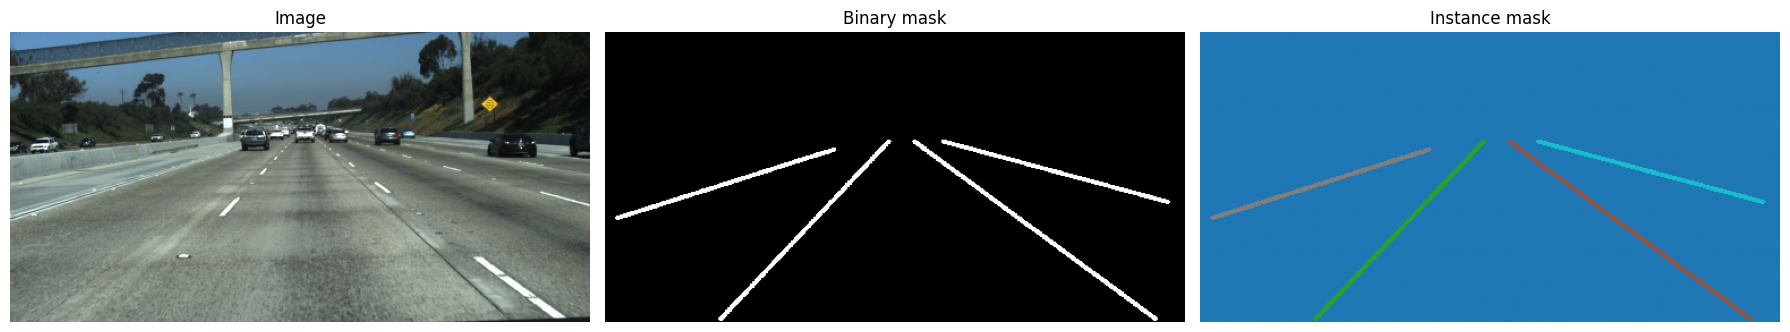

In [ ]:
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

import src.config as cfg
from src.data.dataset import LaneDataset
from src.data.transforms import transform_image

# 1. Build dataset + loader
manifest = f"{cfg.ROOT_DIR}/train.txt"
dataset = LaneDataset(manifest_path=manifest,
                      root_dir=cfg.ROOT_DIR,
                      transform=transform_image)

loader = DataLoader(dataset,
                    batch_size=cfg.BATCH_SIZE,
                    shuffle=True,
                    num_workers=2)

print(f"Dataset length: {len(dataset)}")
print(f"Number of batches: {len(loader)}")

# 2. Pull one batch and inspect shapes / dtypes / value ranges
imgs, bin_masks, inst_masks = next(iter(loader))

print(f"\nimgs        -> shape={tuple(imgs.shape)},        dtype={imgs.dtype},        min={imgs.min():.3f}, max={imgs.max():.3f}")
print(f"bin_masks   -> shape={tuple(bin_masks.shape)},   dtype={bin_masks.dtype},   unique={torch.unique(bin_masks).tolist()}")
print(f"inst_masks  -> shape={tuple(inst_masks.shape)},  dtype={inst_masks.dtype},  unique={torch.unique(inst_masks).tolist()}")

# Expected for batch_size=8, 256x512:
#   imgs       (8, 3, 256, 512), float32, [0, 1]
#   bin_masks  (8, 1, 256, 512), float32, [0., 1.]
#   inst_masks (8, 1, 256, 512), float32 or uint8, e.g. [0, 1, 2, 3, 4]

# 3. Visualize one sample from the batch
i = 0  # change to view different samples in the batch

# image: (C, H, W) -> (H, W, C); cv2 loaded BGR so swap to RGB for display
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

img_np = imgs[i].permute(1, 2, 0).numpy()       # (H, W, C), already RGB
img_np = (img_np * std + mean).clip(0, 1)        # denormalize for display

bin_np  = bin_masks[i].squeeze(0).numpy()
inst_np = inst_masks[i].squeeze(0).numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img_np);                 axes[0].set_title("Image");        axes[0].axis("off")
axes[1].imshow(bin_np, cmap="gray");    axes[1].set_title("Binary mask");  axes[1].axis("off")
axes[2].imshow(inst_np, cmap="tab10");  axes[2].set_title("Instance mask");axes[2].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
import torch
from src.models.encoder import ENetEncoder

enc = ENetEncoder()
x = torch.randn(2, 3, 256, 512)
feats, idx1, idx2, s1, s2, inp = enc(x)

print("features:", feats.shape)        # (2, 128, 32, 64)
print("idx1:    ", idx1.shape)          # (2, 64, 64, 128)
print("idx2:    ", idx2.shape)          # (2, 128, 32, 64)
print("s1:", s1, "  s2:", s2, "  inp:", inp)
print("params:  ", sum(p.numel() for p in enc.parameters()))   # ~310-320k

In [ ]:
import torch
from src.models.encoder import ENetEncoder
from src.models.lanenet import LaneNetDecoder

enc = ENetEncoder()
dec = LaneNetDecoder(out_channels=2)   # binary head

x = torch.randn(2, 3, 256, 512)
feats, idx1, idx2, s1, s2, inp = enc(x)
out = dec(feats, idx1, idx2, s1, s2, inp)

print(out.shape)   # expect (2, 2, 256, 512)
print(sum(p.numel() for p in dec.parameters()))  # ~26-30k

In [ ]:
import torch
from src.models.lanenet import LaneNet

m = LaneNet(embedding_dim=4)
binary, embedding = m(torch.randn(2, 3, 256, 512))

print("binary:   ", binary.shape)     # (2, 2, 256, 512)
print("embedding:", embedding.shape)  # (2, 4, 256, 512)
print("params:   ", sum(p.numel() for p in m.parameters()))  # ~370k

In [ ]:
import torch
import numpy as np
from torch.utils.data import DataLoader
import src.config as cfg
from src.data.dataset import LaneDataset
from src.data.transforms import transform_image

dataset = LaneDataset(
    manifest_path=f"{cfg.ROOT_DIR}/train.txt",
    root_dir=cfg.ROOT_DIR,
    transform=transform_image,
)
loader = DataLoader(dataset, batch_size=8, num_workers=2, shuffle=False)

total_pixels = 0
lane_pixels = 0

for _, bin_masks, _ in loader:
    # bin_masks: (B, 1, H, W) with values {0., 1.}
    total_pixels += bin_masks.numel()
    lane_pixels  += bin_masks.sum().item()

p_lane = lane_pixels / total_pixels
p_bg   = 1.0 - p_lane

# Paper's formula
c = 1.02
w_bg   = 1.0 / np.log(c + p_bg)
w_lane = 1.0 / np.log(c + p_lane)

print(f"p_background = {p_bg:.6f}   weight = {w_bg:.4f}")
print(f"p_lane       = {p_lane:.6f} weight = {w_lane:.4f}")

p_background = 0.972426   weight = 1.4506
p_lane       = 0.027574 weight = 21.5162


In [ ]:
import torch

# Create two 1D tensors (Vectors)
t1 = torch.tensor([1, 2, 3])
t2 = torch.tensor([4, 5, 6])

# Stack them at dim 0 (creates a new dimension at the start)
stacked = torch.stack([t1, t2], dim=0)

print(stacked)

tensor([[1, 2, 3],
        [4, 5, 6]])


In [ ]:
import torch
from src.models.lanenet import LaneNet
from src.loss import compute_loss

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

model = LaneNet(embedding_dim=4).to(device)
B, H, W = 2, 256, 512
img = torch.randn(B, 3, H, W, device=device)

# Fake masks with 3 lane instances each
binary_mask = torch.zeros(B, 1, H, W, device=device)
inst_mask   = torch.zeros(B, 1, H, W, dtype=torch.long, device=device)
for k, lane_y in enumerate([60, 120, 180], start=1):
    binary_mask[:, :, lane_y:lane_y+5, :] = 1.0
    inst_mask[:,   :, lane_y:lane_y+5, :] = k

class_weights = torch.tensor([1.4506, 21.5162], device=device)

binary_logits, embedding = model(img)
total, comps = compute_loss(binary_logits, embedding,
                            binary_mask, inst_mask,
                            class_weights=class_weights)
total.backward()

print(comps)
print("encoder grad norm:",
      sum(p.grad.norm().item() for p in model.encoder.parameters() if p.grad is not None))

{'total': 36.421016693115234, 'binary': 0.8060316443443298, 'disc': 35.614986419677734, 'variance': 0.4657112956047058, 'distance': 35.14874267578125, 'reg': 0.5319617986679077}
encoder grad norm: 494.9077393787011


Check how .pt file works

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

import src.config as cfg
from src.data.dataset import LaneDataset
from src.data.transforms import transform_image
from src.models.lanenet import LaneNet
from src.utils import binary_iou

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load model and checkpoint
model = LaneNet(embedding_dim=4).to(device)
ckpt = torch.load("/content/drive/MyDrive/Lane_Detection_Project/checkpoints/last.pt",
                  map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']}")

Loaded checkpoint from epoch 5


In [6]:
# Pick a sample from validation set
val_ds = LaneDataset(f"{cfg.ROOT_DIR}/val.txt", cfg.ROOT_DIR, transform=transform_image)

idx = 1   # change to look at different samples
img, bin_mask_gt, inst_mask_gt = val_ds[idx]

# Run inference
with torch.no_grad():
    binary_logits, embedding = model(img.unsqueeze(0).to(device))

# Convert to numpy for plotting
binary_pred = binary_logits.argmax(dim=1).squeeze(0).cpu().numpy()  # (H, W) int
binary_prob = torch.softmax(binary_logits, dim=1)[0, 1].cpu().numpy()  # (H, W) lane prob
emb = embedding.squeeze(0).cpu().numpy()                            # (D, H, W)
bin_gt = bin_mask_gt.squeeze(0).numpy()
inst_gt = inst_mask_gt.squeeze(0).numpy()

# Per-sample IoU
iou = binary_iou(binary_logits, bin_mask_gt.unsqueeze(0).to(device))
print(f"Sample {idx}: lane IoU = {iou:.4f}")
print(f"Pred lane pixel ratio: {binary_pred.mean():.4f}")
print(f"GT   lane pixel ratio: {bin_gt.mean():.4f}")

Sample 1: lane IoU = 0.3170
Pred lane pixel ratio: 0.0662
GT   lane pixel ratio: 0.0217


See the binary logits and embeeding shape and values

In [8]:
print("binary_logits ->", tuple(binary_logits.shape), binary_logits.dtype,
      f"min={binary_logits.min():.3f} max={binary_logits.max():.3f} mean={binary_logits.mean():.3f}")

print("embedding     ->", tuple(embedding.shape), embedding.dtype,
      f"min={embedding.min():.3f} max={embedding.max():.3f} mean={embedding.mean():.3f}")

# Pick one pixel and show its values
y, x = 150, 250
print(f"\nPixel ({y},{x}):")
print(f"  binary_logits = {binary_logits[0, :, y, x].cpu().numpy().round(3)}  # [bg, lane]")
print(f"  embedding     = {embedding[0, :, y, x].cpu().numpy().round(3)}      # 4-D vector")

binary_logits -> (1, 2, 256, 512) torch.float32 min=-6.530 max=8.266 mean=0.069
embedding     -> (1, 4, 256, 512) torch.float32 min=-11.913 max=10.448 mean=-0.115

Pixel (150,250):
  binary_logits = [ 3.952 -3.6  ]  # [bg, lane]
  embedding     = [ 0.896 -1.872  2.406 -3.032]      # 4-D vector


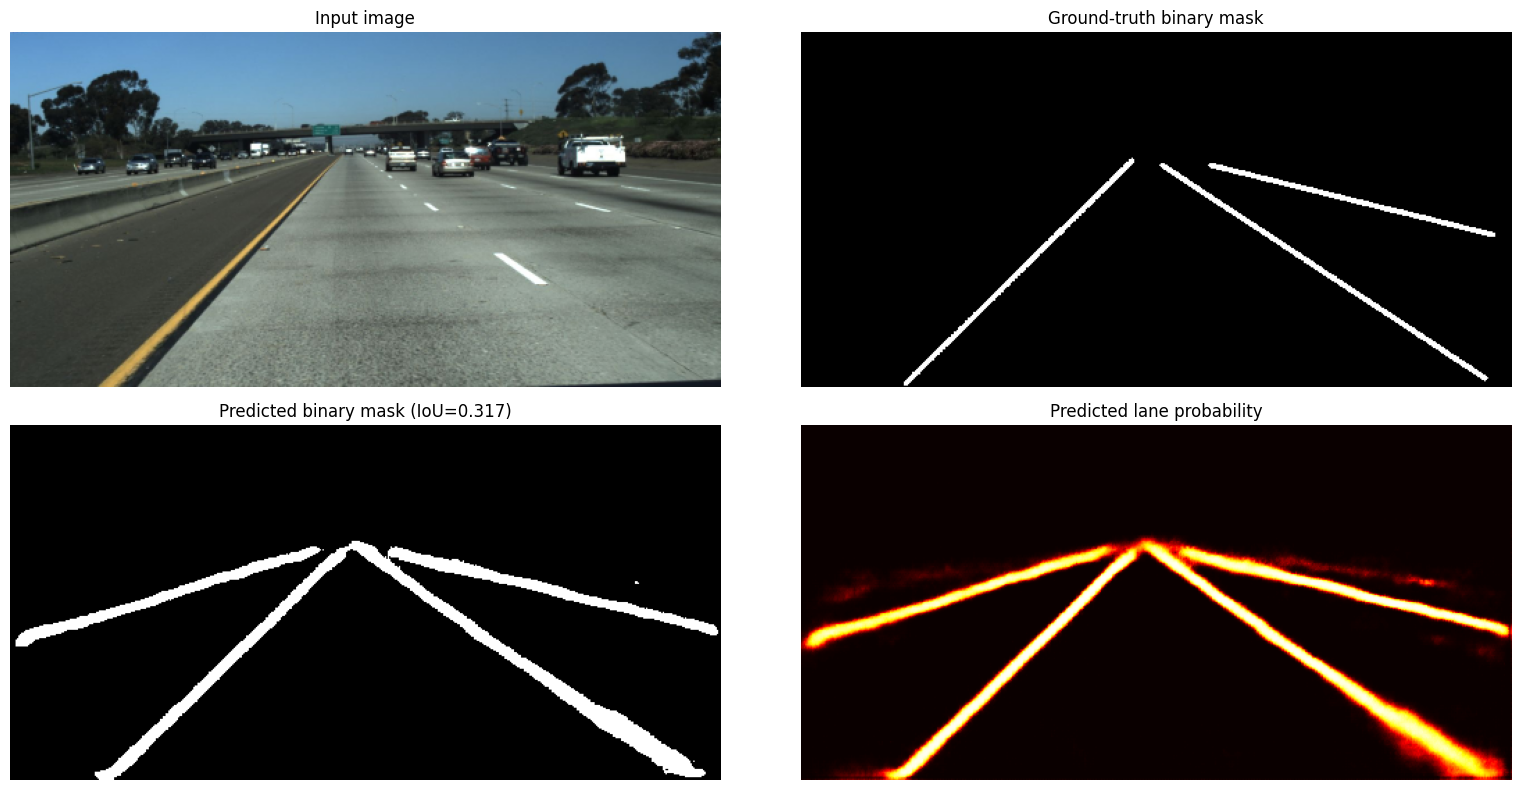

In [7]:
# Denormalize image for display
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
img_disp = img.permute(1, 2, 0).numpy() * std + mean
img_disp = img_disp.clip(0, 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Top-left: input image
axes[0, 0].imshow(img_disp)
axes[0, 0].set_title("Input image")
axes[0, 0].axis("off")

# Top-right: ground-truth lane mask
axes[0, 1].imshow(bin_gt, cmap="gray")
axes[0, 1].set_title("Ground-truth binary mask")
axes[0, 1].axis("off")

# Bottom-left: predicted lane mask (argmax)
axes[1, 0].imshow(binary_pred, cmap="gray")
axes[1, 0].set_title(f"Predicted binary mask (IoU={iou:.3f})")
axes[1, 0].axis("off")

# Bottom-right: predicted lane probability heatmap
axes[1, 1].imshow(binary_prob, cmap="hot", vmin=0, vmax=1)
axes[1, 1].set_title("Predicted lane probability")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

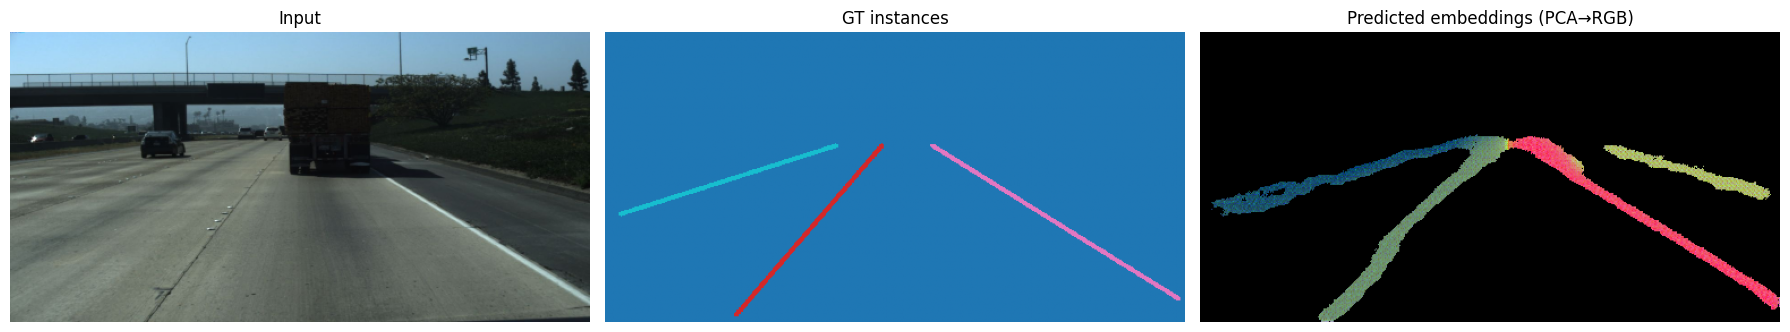

In [ ]:
from sklearn.decomposition import PCA

D, H, W = emb.shape
emb_flat = emb.reshape(D, -1).T          # (H*W, D)

# Only show embedding where the binary mask predicts a lane
lane_mask = binary_pred.astype(bool).flatten()
lane_emb = emb_flat[lane_mask]            # (N_lane_pixels, D)

# PCA those embeddings down to 3 components
pca = PCA(n_components=3)
emb_3d = pca.fit_transform(lane_emb)      # (N, 3)

# Normalize each component to [0, 1] for RGB
emb_3d -= emb_3d.min(axis=0)
emb_3d /= emb_3d.max(axis=0) + 1e-8

# Place back into an image-shaped array
emb_rgb = np.zeros((H * W, 3), dtype=np.float32)
emb_rgb[lane_mask] = emb_3d
emb_rgb = emb_rgb.reshape(H, W, 3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img_disp);                         axes[0].set_title("Input"); axes[0].axis("off")
axes[1].imshow(inst_gt, cmap="tab10");            axes[1].set_title("GT instances"); axes[1].axis("off")
axes[2].imshow(emb_rgb);                          axes[2].set_title("Predicted embeddings (PCA→RGB)"); axes[2].axis("off")
plt.tight_layout(); plt.show()

postprocess

test post processing here

In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt

import src.config as cfg
# Override the Drive path with the local subset
cfg.ROOT_DIR = os.path.abspath("src/data/lane_subset")  # adjust if it's elsewhere
print("ROOT_DIR:", cfg.ROOT_DIR)

from src.data.dataset import LaneDataset
from src.data.transforms import transform_image
from src.postprocess import my_postprocess, draw_lanes
import random


def synthetic_outputs_from_gt(bin_mask, inst_mask, embedding_dim=4, noise=0.1):
    H, W = bin_mask.shape
    binary_logits = np.zeros((2, H, W), dtype=np.float32)
    binary_logits[0] = (1 - bin_mask) * 5.0
    binary_logits[1] = bin_mask * 5.0

    embedding = np.zeros((embedding_dim, H, W), dtype=np.float32)
    for lid in np.unique(inst_mask):
        if lid == 0: continue
        embedding[:, inst_mask == lid] = float(lid) / 50.0
    embedding += np.random.randn(*embedding.shape).astype(np.float32) * noise
    return binary_logits, embedding


# Load the local mini dataset
ds = LaneDataset(f"{cfg.ROOT_DIR}/train.txt", cfg.ROOT_DIR, transform=transform_image)
print(f"Loaded {len(ds)} samples locally")

# Test postprocess on one sample
i = random.randint(0, len(ds)-1)  # pick a random sample each run
img_t, bin_mask_t, inst_mask_t = ds[i]

bin_gt  = bin_mask_t.squeeze(0).numpy().astype(np.uint8)
inst_gt = inst_mask_t.squeeze(0).numpy().astype(np.uint8)

binary_logits, embedding = synthetic_outputs_from_gt(bin_gt, inst_gt)
lanes = my_postprocess(binary_logits, embedding, eps=0.5, min_samples=50)
print(f"Sample {i}: detected {len(lanes)} lanes (GT: {len(np.unique(inst_gt)) - 1})")

# Visualize
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
img_disp = img_t.permute(1, 2, 0).numpy() * std + mean
img_disp = (img_disp.clip(0, 1) * 255).astype(np.uint8)

annotated = draw_lanes(img_disp, lanes)

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(img_disp);                ax[0].set_title("Image"); ax[0].axis("off")
ax[1].imshow(bin_gt, cmap="gray");     ax[1].set_title("GT binary"); ax[1].axis("off")
ax[2].imshow(inst_gt, cmap="tab10");   ax[2].set_title("GT instance"); ax[2].axis("off")
ax[3].imshow(annotated);               ax[3].set_title(f"{len(lanes)} lanes"); ax[3].axis("off")
plt.tight_layout(); plt.show()

ROOT_DIR: /content/LaneDetection/src/data/lane_subset


ImportError: cannot import name 'my_postprocess' from 'src.postprocess' (/content/LaneDetection/src/postprocess.py)